# NFXP — Quantity-Dependent Dynamic Demand

**Oliver Ovdal Eiberg Jørgensen & Solveig Røndal-Liniger** — Dynamisk Programmering, Forår 2026

---

## Model

Forbrugeren vælger hvert periode $t$: $y_{it} \in \mathcal{Y} = \{0\} \cup \{(j,q) : j \in \{1,\ldots,J\},\, q \in \{1,\ldots,Q\}\}$

**Tilstandsvariabel:** $x_{it} = (\ell_{it},\, d_{it},\, q_{it},\, e_t)$ hvor
- $\ell_{it}$: sidst-købt mærke
- $d_{it}$: tid siden seneste køb
- $q_{it}$: mængde købt ved seneste køb
- $e_t$: promotionsstatus (eksogen Markov-kæde)

**Nytte (ligning 1):**
$$U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}(\ell_{it},\, q_{it},\, d_{it}) & \text{hvis } y_{it}=0 \\
  \alpha(j) - \gamma\cdot q\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it},\, j) & \text{hvis } y_{it}=(j,q)
\end{cases}$$

**Parametrisering:** $\beta^{\rm dep}(\ell, q, d) = \beta^{\rm dep}[\ell, q] \times d$ (lineær i $d$, rate afhænger af mærke og sidst-købt mængde)

**Transitionsregel:**
$$
(\ell_{i,t+1},\, d_{i,t+1},\, q_{i,t+1}) = \begin{cases}
  (\ell_{it},\, d_{it}+1,\, q_{it}) & \text{hvis } y_{it}=0 \\
  (j,\, 1,\, q) & \text{hvis } y_{it}=(j,q)
\end{cases}
$$

**Estimator:** NFXP (Rust 1987) — Nelder-Mead ydre løkke, VFI indre løkke.

## 1. Import

In [1]:
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## 2. Primitiver og sande parametre

In [2]:
# ── Modeldimensioner ──────────────────────────────────────────────────────────
J     = 2       # antal mærker
T     = 52      # perioder pr. forbruger
N     = 2_000   # forbrugere pr. panel
D_MAX = 3       # varighedsloft: d_idx ∈ {0,...,D_MAX}, papir-d ∈ {1,...,D_MAX+1}
DELTA = 0.95    # diskonteringsfaktor
Q_MAX = 2       # maks. købsmængde

# ── Prisniveauer ──────────────────────────────────────────────────────────────
BASE_PRICES   = np.array([7.0, 10.0])   # regulære enhedspriser
PROMO_DISC    = np.array([1.5,  2.0])   # promotionsrabat
PROMO_ENTRY   = 0.18                    # P(promotion starter)
PROMO_PERSIST = 0.62                    # P(promotion fortsætter)

# ── Sande strukturelle parametre (DGP) ───────────────────────────────────────
#
#   u(0)     = α(ℓ)  − β^dep[ℓ, q_last] · d
#   u((j,q)) = α(j)  − γ · q · p(j) − β^sc(ℓ, j)
#
ALPHA_TRUE    = np.array([0.0,  0.50])          # α(1)=0 er normaliseringen
GAMMA_TRUE    = 0.05                             # marginal udgiftsdi-nytte
BETA_SC_TRUE  = np.array([[0.00, 0.30],          # β^sc[k,j]: skifteomk. k→j
                           [0.25, 0.00]])

# β^dep[ℓ, q] — shape (J, Q_MAX)
# Række = mærke (0-indeks), kolonne = sidst-købt mængde (0=q1, 1=q2)
# Større mængde sidst → lavere afskrivningsrate (mere lager)
BETA_DEP_TRUE = np.array([[0.35, 0.20],          # mærke 1: [q=1, q=2]
                           [0.35, 0.20]])         # mærke 2: [q=1, q=2]

# ── Monte Carlo ───────────────────────────────────────────────────────────────
MC_REPS = 20
MC_SEED = 2024

# ── Valg-indeksering ─────────────────────────────────────────────────────────
# choice c = 0            → ingen køb
# choice c = 1+j*Q_MAX+q  → køb mærke (j+1), mængde (q+1),  j,q ∈ {0,...}
N_CHOICES = 1 + J * Q_MAX   # 5 valg: {0, (1,1), (1,2), (2,1), (2,2)}

# ── Parametervektor ───────────────────────────────────────────────────────────
PARAM_NAMES = ["alpha_2", "gamma", "beta_sc_12", "beta_sc_21",
               "bdep_1_q1", "bdep_1_q2", "bdep_2_q1", "bdep_2_q2"]

THETA_TRUE = np.array([
    ALPHA_TRUE[1],
    GAMMA_TRUE,
    BETA_SC_TRUE[0, 1],
    BETA_SC_TRUE[1, 0],
    BETA_DEP_TRUE[0, 0], BETA_DEP_TRUE[0, 1],
    BETA_DEP_TRUE[1, 0], BETA_DEP_TRUE[1, 1],
])

print("Sande parametre:")
for n, v in zip(PARAM_NAMES, THETA_TRUE):
    print(f"  {n:<14} = {v}")
print(f"\nN_CHOICES={N_CHOICES}  |  BASE_PRICES={BASE_PRICES}  |  Q_MAX={Q_MAX}  |  D_MAX={D_MAX}")

Sande parametre:
  alpha_2        = 0.5
  gamma          = 0.05
  beta_sc_12     = 0.3
  beta_sc_21     = 0.25
  bdep_1_q1      = 0.35
  bdep_1_q2      = 0.2
  bdep_2_q1      = 0.35
  bdep_2_q2      = 0.2

N_CHOICES=5  |  BASE_PRICES=[ 7. 10.]  |  Q_MAX=2  |  D_MAX=3


## 3. Prisproces — Hi-Lo (Antagelse 2.1)

Promotionsstatus $e_t \in \{0,1\}^J$ er en binær vektor. Med $J=2$ er der $2^2=4$ mulige tilstande. Mærkernes promotioner følger uafhængige to-tilstands Markov-kæder, og den fælles overgangssandsynlighed er produktet af de marginale.

In [3]:
promo_states = np.array(
    [[(s >> j) & 1 for j in range(J)] for s in range(2 ** J)], dtype=int
)
N_PROMO = len(promo_states)


def make_promo_transition() -> np.ndarray:
    trans = np.empty((N_PROMO, N_PROMO))
    for s, curr in enumerate(promo_states):
        prob_on = np.where(curr == 1, PROMO_PERSIST, PROMO_ENTRY)
        for sp, nxt in enumerate(promo_states):
            trans[s, sp] = np.prod(np.where(nxt == 1, prob_on, 1.0 - prob_on))
    return trans


PROMO_TRANS = make_promo_transition()

print("Enhedspriser pr. promotionstilstand:")
for s, e in enumerate(promo_states):
    p = BASE_PRICES - PROMO_DISC * e
    print(f"  Tilstand {s}: e={tuple(e)}  p={p}  |  q=2 koster: {2*p}")

Enhedspriser pr. promotionstilstand:
  Tilstand 0: e=(0, 0)  p=[ 7. 10.]  |  q=2 koster: [14. 20.]
  Tilstand 1: e=(1, 0)  p=[ 5.5 10. ]  |  q=2 koster: [11. 20.]
  Tilstand 2: e=(0, 1)  p=[7. 8.]  |  q=2 koster: [14. 16.]
  Tilstand 3: e=(1, 1)  p=[5.5 8. ]  |  q=2 koster: [11. 16.]


## 4. Nyttefunktion (ligning 1)

$$U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}[\ell_{it}, q_{it}] \cdot d_{it} & \text{hvis } y_{it}=0 \\
  \alpha(j) - \gamma\cdot q\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it}, j) & \text{hvis } y_{it}=(j,q)
\end{cases}$$

- $\gamma \cdot q \cdot p_{it}(j)$: di-nytte fra total udgift (lineær i $q$ og $p$)
- $\beta^{\rm dep}[\ell, q] \times d$: lagerafskrivning, rate afhænger af mærke og sidst-købt mængde
- $\beta^{\rm sc}(\ell, j)$: mærkeskifteomkostning

In [4]:
def flow_util(choice, last_brand, last_qty, duration, e_idx,
              alpha, gamma, beta_sc, beta_dep) -> float:
    """
    Deterministisk periodennytte.

    choice   : 0 = ingen køb; c = 1 + j_idx*Q_MAX + q_buy_idx → køb (j,q)
    last_brand: ℓ ∈ {1,...,J}
    last_qty  : q_last ∈ {1,...,Q_MAX}  (mængde ved seneste køb)
    duration  : papir-d = d_idx + 1  ∈ {1,...,D_MAX+1}
    beta_dep  : (J, Q_MAX) array — afskrivningsrate pr. mærke og mængde
    """
    l     = last_brand - 1
    q_idx = last_qty   - 1
    prices = BASE_PRICES - PROMO_DISC * promo_states[e_idx]

    if choice == 0:
        # Ingen køb: lagerafskrivning afhænger af mærke og sidst-købt mængde
        return alpha[l] - beta_dep[l, q_idx] * duration

    j_idx = (choice - 1) // Q_MAX        # mærkeindeks (0-indeks)
    q_buy = (choice - 1) % Q_MAX + 1     # købt mængde: 1 eller 2
    return alpha[j_idx] - gamma * q_buy * prices[j_idx] - beta_sc[l, j_idx]

## 5. Indre løkke: Value Function Iteration (VFI)

**Tilstandsrum:** $(\ell, q_{\rm last}, d, e)$, $J \times Q_{\max} \times (D_{\max}+1) \times N_e = 2\times 2\times 4\times 4 = 64$ tilstande.

$V$ har shape `(J, Q_MAX, D_MAX+1, N_PROMO)`.

Transitionsregel i VFI:
- Ingen køb: $(\ell, q_{\rm last}, d_{\rm idx}) \to (\ell, q_{\rm last}, \min(d_{\rm idx}+1, D_{\rm MAX}))$
- Køb $(j, q)$: $(\ell, q_{\rm last}, d_{\rm idx}) \to (j, q, 0)$ (papir-$d=1$)

In [5]:
def solve_vfi(alpha, gamma, beta_sc, beta_dep,
              tol: float = 1e-10, max_iter: int = 2_000) -> np.ndarray:
    """
    VFI for modellen med mændeafhængig β^dep.

    V shape: (J, Q_MAX, D_MAX+1, N_PROMO).
    d_idx ∈ {0,...,D_MAX} svarer til papir-d = d_idx + 1.
    """
    V = np.zeros((J, Q_MAX, D_MAX + 1, N_PROMO))

    for _ in range(max_iter):
        # Forventet fortsættelsesværdi (integrer over promotionsproces)
        EV = (V.reshape(J * Q_MAX * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
              ).reshape(J, Q_MAX, D_MAX + 1, N_PROMO)

        V_new = np.empty_like(V)

        for l_idx in range(J):
            ell = l_idx + 1
            for q_idx in range(Q_MAX):
                q_last = q_idx + 1
                for d in range(D_MAX + 1):
                    d_next = min(d + 1, D_MAX)   # d_idx ved ingen køb
                    d_dur  = d + 1               # papir-d til nyttefunktionen
                    for e in range(N_PROMO):
                        Q_vals = np.empty(N_CHOICES)

                        # Ingen køb: tilstand → (ℓ, q_last, d_next, e')
                        Q_vals[0] = (
                            flow_util(0, ell, q_last, d_dur, e,
                                      alpha, gamma, beta_sc, beta_dep)
                            + DELTA * EV[l_idx, q_idx, d_next, e]
                        )

                        # Køb (j, q): tilstand → (j, q, d_idx=0, e')  [papir d=1]
                        for j_idx in range(J):
                            for q_buy_idx in range(Q_MAX):
                                c = 1 + j_idx * Q_MAX + q_buy_idx
                                Q_vals[c] = (
                                    flow_util(c, ell, q_last, d_dur, e,
                                              alpha, gamma, beta_sc, beta_dep)
                                    + DELTA * EV[j_idx, q_buy_idx, 0, e]
                                )

                        qm = Q_vals.max()
                        V_new[l_idx, q_idx, d, e] = qm + np.log(np.exp(Q_vals - qm).sum())

        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V

## 6. Betingede valgssandsynligheder (CCPs)

$$P(c \mid s;\theta) = \frac{\exp(Q_c)}{\sum_{k}\exp(Q_k)}, \quad Q_c = u(c, s) + \delta\cdot EV(\text{næste tilstand})$$

`P` shape: `(J, Q_MAX, D_MAX+1, N_PROMO, N_CHOICES)`.

In [6]:
def compute_ccps(V, alpha, gamma, beta_sc, beta_dep) -> np.ndarray:
    """
    Beregn CCPs fra løst værdifunktion V.
    P shape: (J, Q_MAX, D_MAX+1, N_PROMO, N_CHOICES).
    """
    EV = (V.reshape(J * Q_MAX * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
          ).reshape(J, Q_MAX, D_MAX + 1, N_PROMO)

    P = np.empty((J, Q_MAX, D_MAX + 1, N_PROMO, N_CHOICES))

    for l_idx in range(J):
        ell = l_idx + 1
        for q_idx in range(Q_MAX):
            q_last = q_idx + 1
            for d in range(D_MAX + 1):
                d_next = min(d + 1, D_MAX)
                d_dur  = d + 1
                for e in range(N_PROMO):
                    Q_vals = np.empty(N_CHOICES)
                    Q_vals[0] = (
                        flow_util(0, ell, q_last, d_dur, e,
                                  alpha, gamma, beta_sc, beta_dep)
                        + DELTA * EV[l_idx, q_idx, d_next, e]
                    )
                    for j_idx in range(J):
                        for q_buy_idx in range(Q_MAX):
                            c = 1 + j_idx * Q_MAX + q_buy_idx
                            Q_vals[c] = (
                                flow_util(c, ell, q_last, d_dur, e,
                                          alpha, gamma, beta_sc, beta_dep)
                                + DELTA * EV[j_idx, q_buy_idx, 0, e]
                            )
                    w = np.exp(Q_vals - Q_vals.max())
                    P[l_idx, q_idx, d, e, :] = w / w.sum()

    return P

## 7. Datasimulering

`simulate_panel` simulerer et forbrugerpanel fra modelens CCPs og returnerer:
- `Y_choice` ∈ {0,...,N_CHOICES−1}: fuldt valg inkl. mærke og mængde
- `L`: sidst-købt mærke (tilstandsvariabel)
- `Q_LAST`: sidst-købt mængde (tilstandsvariabel)
- `D`: varighed siden seneste køb, d_idx ∈ {0,...,D_MAX}
- `E_IDX`: promotionsstatus

In [7]:
def _sample_rows(rng, row_probs: np.ndarray) -> np.ndarray:
    """Vektoriseret kategorisk trækning: én observation pr. række i row_probs."""
    u = rng.random(len(row_probs))
    cumsum = np.cumsum(row_probs, axis=1)
    return (u[:, None] > cumsum).sum(axis=1)


def simulate_panel(P_true: np.ndarray,
                   n_consumers: int = N, n_periods: int = T,
                   seed=None) -> dict:
    """
    Simulér forbrugerpanel fra CCPs.
    P_true shape: (J, Q_MAX, D_MAX+1, N_PROMO, N_CHOICES).

    Returnerer dict: Y_choice, L, Q_LAST, D, E_IDX  — alle (n_consumers, n_periods).
    """
    rng = np.random.default_rng(seed)

    Y_choice = np.zeros((n_consumers, n_periods), dtype=int)
    L        = np.zeros((n_consumers, n_periods), dtype=int)
    Q_LAST   = np.ones( (n_consumers, n_periods), dtype=int)
    D        = np.zeros((n_consumers, n_periods), dtype=int)
    E_IDX    = np.zeros((n_consumers, n_periods), dtype=int)

    ell   = rng.integers(1, J + 1,     size=n_consumers)
    q_lst = np.ones(n_consumers, dtype=int)               # initialisér q_last = 1
    dur   = rng.integers(0, D_MAX + 1, size=n_consumers)
    e_idx = rng.integers(0, N_PROMO,   size=n_consumers)

    for t in range(n_periods):
        L[:, t]      = ell
        Q_LAST[:, t] = q_lst
        D[:, t]      = dur
        E_IDX[:, t]  = e_idx

        # CCP-opslag: tilstand (ℓ-1, q_last-1, min(d,D_MAX), e)
        probs = P_true[ell - 1, q_lst - 1, np.minimum(dur, D_MAX), e_idx, :]
        y = _sample_rows(rng, probs)
        Y_choice[:, t] = y

        # Afkod mærke og mængde fra valgsindeks
        bought       = y > 0
        brand_bought = np.where(bought, (y - 1) // Q_MAX + 1, ell)
        qty_bought   = np.where(bought, (y - 1) % Q_MAX  + 1, q_lst)

        # Opdater tilstandsvariable (transitionsregel)
        ell   = brand_bought
        q_lst = qty_bought
        dur   = np.where(bought, 0, np.minimum(dur + 1, D_MAX))
        e_idx = _sample_rows(rng, PROMO_TRANS[e_idx])

    return {"Y_choice": Y_choice, "L": L, "Q_LAST": Q_LAST, "D": D, "E_IDX": E_IDX}

## 8. Log-sandsynlighed og NFXP

**Log-likelihood:**
$$\ell(\theta) = \sum_{i,t} \log P(y_{it} \mid \ell_{it}, q_{it}, d_{it}, e_{it}; \theta)$$

**NFXP (Rust 1987):** ydre Nelder-Mead minimerer $-\ell(\theta)$; indre VFI løser Bellman-ligningen ved hvert kandidat-$\theta$.

**Parametervektor:**
$$\theta = [\alpha_2,\; \gamma,\; \beta^{sc}_{12},\; \beta^{sc}_{21},\; \beta^{dep}_{1,q1},\; \beta^{dep}_{1,q2},\; \beta^{dep}_{2,q1},\; \beta^{dep}_{2,q2}]$$

In [8]:
def log_likelihood(data: dict, P: np.ndarray) -> float:
    """Summeret log-sandsynlighed over alle (i,t)-observationer."""
    Y = data["Y_choice"]
    L, Q, D, E = data["L"], data["Q_LAST"], data["D"], data["E_IDX"]
    probs = P[L - 1, Q - 1, D, E, Y]
    return float(np.sum(np.log(np.maximum(probs, 1e-300))))


def unpack(theta: np.ndarray):
    """[alpha_2, gamma, beta_sc_12, beta_sc_21, bdep_1q1, bdep_1q2, bdep_2q1, bdep_2q2]"""
    alpha    = np.array([0.0, theta[0]])
    gamma    = float(theta[1])
    beta_sc  = np.array([[0.0, theta[2]], [theta[3], 0.0]])
    beta_dep = theta[4:8].reshape(J, Q_MAX)   # (J, Q_MAX)
    return alpha, gamma, beta_sc, beta_dep


def nfxp_objective(theta: np.ndarray, data: dict) -> float:
    alpha, gamma, beta_sc, beta_dep = unpack(theta)
    V = solve_vfi(alpha, gamma, beta_sc, beta_dep)
    P = compute_ccps(V, alpha, gamma, beta_sc, beta_dep)
    return -log_likelihood(data, P)


def estimate_nfxp(data: dict, theta0: np.ndarray = None, verbose: bool = False):
    """Estimer modellen med NFXP (Nelder-Mead)."""
    if theta0 is None:
        theta0 = np.array([0.1, 0.03, 0.3, 0.3, 0.2, 0.1, 0.2, 0.1])
    return minimize(
        fun=nfxp_objective,
        x0=theta0,
        args=(data,),
        method="Nelder-Mead",
        options={"maxiter": 15_000, "xatol": 1e-5, "fatol": 1e-5,
                 "disp": verbose, "adaptive": True},
    )

## 9. Pilot — enkelt panel

Verificér at VFI konvergerer, simuleringen ser fornuftig ud, og at NFXP gendanner de sande parametre fra et enkelt panel.

In [9]:
print("Trin 1: Løser DP ved sande parametre...")
a0, g0, sc0, dep0 = unpack(THETA_TRUE)
V_true = solve_vfi(a0, g0, sc0, dep0)
P_true = compute_ccps(V_true, a0, g0, sc0, dep0)
print("  VFI konvergeret.")

print(f"\nTrin 2: Simulerer panel (N={N}, T={T})...")
data_pilot = simulate_panel(P_true, seed=42)
Y = data_pilot["Y_choice"]
print(f"  Ingen køb:  {(Y == 0).mean():.1%}")
for j in range(1, J + 1):
    for q in range(1, Q_MAX + 1):
        c = 1 + (j - 1) * Q_MAX + (q - 1)
        print(f"  Mærke {j}, mængde {q}: {(Y == c).mean():.1%}")

print("\nTrin 3: Estimerer med NFXP...")
theta0_pilot = THETA_TRUE + np.array([0.05, 0.005, 0.05, 0.05, 0.02, 0.01, 0.02, 0.01])
t0 = time.perf_counter()
res_pilot = estimate_nfxp(data_pilot, theta0=theta0_pilot)
t1 = time.perf_counter() - t0
print(f"  Tid: {t1:.1f}s  |  Konvergeret: {res_pilot.success}  |  Iterationer: {res_pilot.nit}")

print("\n" + "─" * 55)
df_pilot = pd.DataFrame({
    "Parameter": PARAM_NAMES,
    "Sand":      THETA_TRUE,
    "NFXP":      res_pilot.x,
    "Bias":      res_pilot.x - THETA_TRUE,
})
print(df_pilot.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

Trin 1: Løser DP ved sande parametre...
  VFI konvergeret.

Trin 2: Simulerer panel (N=2000, T=52)...
  Ingen køb:  25.9%
  Mærke 1, mængde 1: 15.2%
  Mærke 1, mængde 2: 11.4%
  Mærke 2, mængde 1: 28.5%
  Mærke 2, mængde 2: 19.0%

Trin 3: Estimerer med NFXP...
  Tid: 172.4s  |  Konvergeret: True  |  Iterationer: 368

───────────────────────────────────────────────────────
 Parameter    Sand    NFXP    Bias
   alpha_2 +0.5000 +0.5049 +0.0049
     gamma +0.0500 +0.0517 +0.0017
beta_sc_12 +0.3000 +0.3082 +0.0082
beta_sc_21 +0.2500 +0.2441 -0.0059
 bdep_1_q1 +0.3500 +0.3709 +0.0209
 bdep_1_q2 +0.2000 +0.2077 +0.0077
 bdep_2_q1 +0.3500 +0.3590 +0.0090
 bdep_2_q2 +0.2000 +0.2034 +0.0034


## 10. Monte Carlo

For hver replikation:
1. Simulér nyt panel fra DGP ($\beta^{\rm dep}(\ell, q, d)$)
2. Estimér modellen med NFXP
3. Registrér estimater, bias og RMSE

**Forventet resultat:** lav RMSE og bias tæt på nul for alle 8 parametre.

In [10]:
def run_monte_carlo(n_reps: int = MC_REPS, seed: int = MC_SEED):
    rng_master = np.random.default_rng(seed)
    rep_seeds  = rng_master.integers(0, 1_000_000, size=n_reps)

    # Løs DP én gang ved sande parametre
    a_t, g_t, sc_t, dep_t = unpack(THETA_TRUE)
    V_t = solve_vfi(a_t, g_t, sc_t, dep_t)
    P_t = compute_ccps(V_t, a_t, g_t, sc_t, dep_t)

    print(f"MC  |  J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={n_reps}")
    print(f"DGP: β^dep[:,q1]={BETA_DEP_TRUE[:,0]}, β^dep[:,q2]={BETA_DEP_TRUE[:,1]}\n")

    rows = []
    for rep in range(1, n_reps + 1):
        data = simulate_panel(P_t, n_consumers=N, n_periods=T,
                              seed=int(rep_seeds[rep - 1]))

        rng_s  = np.random.default_rng(int(rep_seeds[rep - 1]) + 999)
        pert   = rng_s.normal(0, 0.05, size=8)
        theta0 = THETA_TRUE + pert

        t0 = time.perf_counter()
        r  = estimate_nfxp(data, theta0=theta0)
        t1 = time.perf_counter() - t0

        print(f"  Rep {rep:>3}/{n_reps}  conv={r.success}  ({t1:>4.0f}s)")

        for k, name in enumerate(PARAM_NAMES):
            rows.append({
                "rep":       rep,
                "param":     name,
                "true":      THETA_TRUE[k],
                "estimate":  r.x[k],
                "bias":      r.x[k] - THETA_TRUE[k],
                "sq_error":  (r.x[k] - THETA_TRUE[k]) ** 2,
                "converged": int(r.success),
            })

    df = pd.DataFrame(rows)
    summary = pd.DataFrame([{
        "param":     name,
        "true":      THETA_TRUE[i],
        "mean_est":  df[df["param"] == name]["estimate"].mean(),
        "bias":      df[df["param"] == name]["bias"].mean(),
        "std":       df[df["param"] == name]["estimate"].std(ddof=1),
        "rmse":      np.sqrt(df[df["param"] == name]["sq_error"].mean()),
        "conv_rate": df[df["param"] == name]["converged"].mean(),
    } for i, name in enumerate(PARAM_NAMES)])

    return df, summary

In [11]:
results, summary = run_monte_carlo()

MC  |  J=2, T=52, N=2000, D_MAX=3, reps=20
DGP: β^dep[:,q1]=[0.35 0.35], β^dep[:,q2]=[0.2 0.2]

  Rep   1/20  conv=True  ( 195s)
  Rep   2/20  conv=True  ( 194s)
  Rep   3/20  conv=True  ( 183s)
  Rep   4/20  conv=True  ( 225s)
  Rep   5/20  conv=True  ( 280s)
  Rep   6/20  conv=True  ( 268s)
  Rep   7/20  conv=True  ( 233s)
  Rep   8/20  conv=True  ( 242s)
  Rep   9/20  conv=True  ( 212s)
  Rep  10/20  conv=True  ( 184s)
  Rep  11/20  conv=True  ( 225s)
  Rep  12/20  conv=True  ( 219s)
  Rep  13/20  conv=True  ( 225s)
  Rep  14/20  conv=True  ( 246s)
  Rep  15/20  conv=True  ( 253s)
  Rep  16/20  conv=True  ( 233s)
  Rep  17/20  conv=True  ( 209s)
  Rep  18/20  conv=True  ( 215s)
  Rep  19/20  conv=True  ( 196s)
  Rep  20/20  conv=True  ( 215s)


## 11. Resultater

In [12]:
print("=" * 65)
print(r"NFXP Monte Carlo — β^dep(ℓ, q_last, d) model")
print(f"J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={MC_REPS}")
print("=" * 65)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

results.to_csv("nfxp_mc_results.csv", index=False)
summary.to_csv("nfxp_mc_summary.csv", index=False)
print("\nGemt: nfxp_mc_results.csv  og  nfxp_mc_summary.csv")

NFXP Monte Carlo — β^dep(ℓ, q_last, d) model
J=2, T=52, N=2000, D_MAX=3, reps=20
     param   true  mean_est    bias    std   rmse  conv_rate
   alpha_2 0.5000    0.4966 -0.0034 0.0423 0.0413     1.0000
     gamma 0.0500    0.0503  0.0003 0.0006 0.0006     1.0000
beta_sc_12 0.3000    0.1817 -0.1183 0.8519 0.8387     1.0000
beta_sc_21 0.2500    0.3649  0.1149 0.8537 0.8400     1.0000
 bdep_1_q1 0.3500    0.3499 -0.0001 0.0104 0.0102     1.0000
 bdep_1_q2 0.2000    0.2000 -0.0000 0.0148 0.0145     1.0000
 bdep_2_q1 0.3500    0.3525  0.0025 0.0080 0.0082     1.0000
 bdep_2_q2 0.2000    0.2027  0.0027 0.0049 0.0055     1.0000

Gemt: nfxp_mc_results.csv  og  nfxp_mc_summary.csv


## 12. Visualisering

Boxplots for alle 8 parametre over Monte Carlo-replikationerne sammenlignet med de sande værdier.

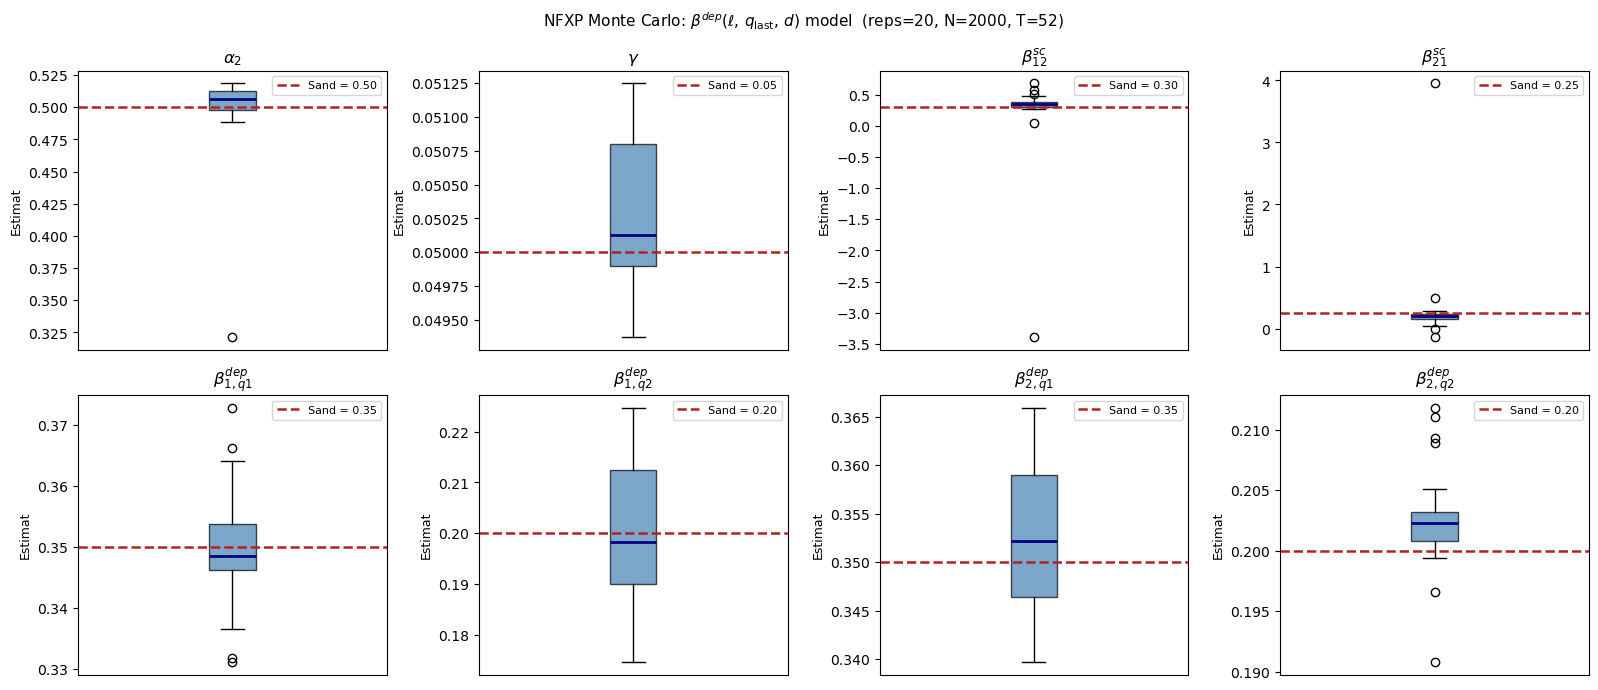

In [13]:
latex_lbl = {
    "alpha_2":    r"$\alpha_2$",
    "gamma":      r"$\gamma$",
    "beta_sc_12": r"$\beta^{sc}_{12}$",
    "beta_sc_21": r"$\beta^{sc}_{21}$",
    "bdep_1_q1":  r"$\beta^{dep}_{1,q1}$",
    "bdep_1_q2":  r"$\beta^{dep}_{1,q2}$",
    "bdep_2_q1":  r"$\beta^{dep}_{2,q1}$",
    "bdep_2_q2":  r"$\beta^{dep}_{2,q2}$",
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, (i, name) in zip(axes, enumerate(PARAM_NAMES)):
    est    = results[results["param"] == name]["estimate"].to_numpy()
    true_v = THETA_TRUE[i]
    ax.boxplot(est, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="navy", linewidth=2))
    ax.axhline(true_v, color="firebrick", lw=1.8, ls="--",
               label=f"Sand = {true_v:.2f}")
    ax.set_title(latex_lbl.get(name, name), fontsize=12)
    ax.set_ylabel("Estimat", fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.NullLocator())

fig.suptitle(
    r"NFXP Monte Carlo: $\beta^{dep}(\ell,\, q_{\rm last},\, d)$ model"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("nfxp_mc_boxplots.pdf", bbox_inches="tight")
plt.show()

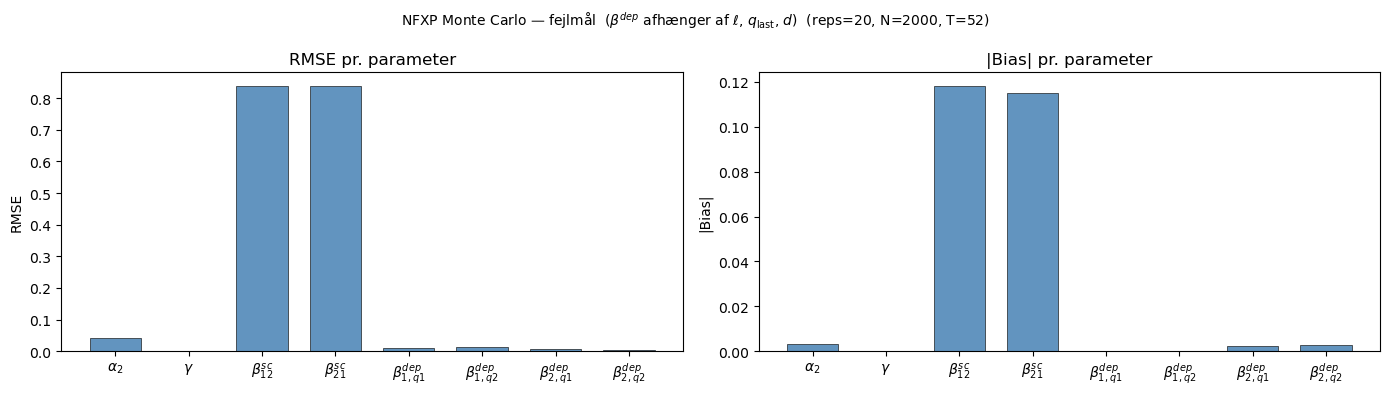

In [14]:
# Bias og RMSE søjlediagram
labels   = [latex_lbl.get(n, n) for n in PARAM_NAMES]
bias_abs = [abs(summary.loc[summary["param"] == n, "bias"].values[0]) for n in PARAM_NAMES]
rmse_v   = [summary.loc[summary["param"] == n, "rmse"].values[0]      for n in PARAM_NAMES]

x = np.arange(len(PARAM_NAMES))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, vals, ylabel, title in [
    (axes[0], rmse_v,   "RMSE",   "RMSE pr. parameter"),
    (axes[1], bias_abs, "|Bias|", "|Bias| pr. parameter"),
]:
    ax.bar(x, vals, 2 * w, color="steelblue", alpha=0.85, edgecolor="black", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="black", lw=0.5)

fig.suptitle(
    r"NFXP Monte Carlo — fejlmål  ($\beta^{dep}$ afhænger af $\ell$, $q_{\rm last}$, $d$)"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=10,
)
plt.tight_layout()
plt.savefig("nfxp_mc_bias_rmse.pdf", bbox_inches="tight")
plt.show()